# Learning to Implement Flow-Matching

In [1]:
from collections.abc import Callable
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import rdkit.Chem as Chem
import torch
import torch.distributions as td
from torch.distributions.mixture_same_family import MixtureSameFamily
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import save_image
from tqdm import tqdm
from typing import Tuple
from wand.image import Image as WImage

import sys
sys.path.append("/home/alzub/projects/ggdl_self_learn/code/")
from plot_utils import set_plot_style
from gnn_.datasets_ import ProcessedInMemoryDataset
from data_proc.mol_preproc import TU_MUTAG_CONFIG, create_processor_list, mol_from_graph, fix_nitro_charges
from generative.conditioning import MLPTimeDependent, UNetTimeClassDependent
from generative.base_dists import GaussianBase
from generative.flow_matching import (
    GaussianProbabilityPath, LinearGaussianSchedule, SqrtGaussianSchedule,
    FlowMatchingModel
)
from solver_.ode_solvers import explicit_euler_fixed

/home/alzub/miniconda3/envs/ggdl/lib/python3.12/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/alzub/miniconda3/envs/ggdl/lib/python3.12/site-packages/torch_scatter/_scatter_cuda.so: undefined symbol: _ZN2at23SavedTensorDefaultHooks11set_tracingEb
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/alzub/miniconda3/envs/ggdl/lib/python3.12/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /home/alzub/miniconda3/envs/ggdl/lib/python3.12/site-packages/torch_sparse/_spmm_cuda.so: undefined symbol: _ZN2at23SavedTensorDefaultHooks11set_tracingEb
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


In [2]:
set_plot_style()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PROJECT_DIR = Path("/home/alzub/projects/ggdl_self_learn")
DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = DATA_DIR / "models/flow_matching"
SAMPLE_DIR = DATA_DIR / "samples/flow_matching"

plt.rcParams["animation.html"] = "jshtml"
matplotlib.rcParams['animation.embed_limit'] = 2**128
plt.ioff()

FM_NAME_MAP = {
    "gaussot": "Gaussian Linear/OT",
    "gausssqrt": "Gaussian Sqrt. Variance"
}

## 0. Prerequisites

### 0.1 Toy Distributions

In [3]:
class TwoGaussians:
    def __init__(self):
        """
        A simple class to define an uneven mixture of two Gaussians.
        """

        mixture = td.Categorical(torch.tensor([1/5, 4/5]))
        components = td.Independent(td.Normal(
            torch.Tensor([
                [0.75, 0.75],
                [0.25, 0.25]
            ]),
            torch.Tensor([
                [0.1, 0.1],
                [0.1, 0.1]
            ])
        ), 1)
        self.distribution = MixtureSameFamily(mixture, components)

        self.xlim = (0, 1)
        self.ylim = (0, 1)

    def __call__(self):
        """
        Return the distribution.
        Returns:
        distribution: [torch.distributions.Distribution]
        """
        return self.distribution

class ExtendedUniform(td.Uniform):
    def __init__(self, low, high, validate_args=None, outside_value=-float('inf')):
        """
        A uniform distribution that returns a constant value for values outside the support
        """
        super(ExtendedUniform, self).__init__(low, high, validate_args)
        self.outside_value = outside_value

    def log_prob(self, value):
        # Check if the value is within the support
        in_support = (value >= self.low) & (value <= self.high)
        safe_value = torch.where(in_support, value, self.low)
        log_prob = super().log_prob(safe_value)
        
        # Set log_prob to self.outside_value for values outside the support
        log_prob = torch.where(in_support, log_prob, torch.full_like(log_prob, self.outside_value))
        return log_prob
    
    @td.constraints.dependent_property(is_discrete=False, event_dim=0)
    def support(self):
        return td.constraints.real

class Chequerboard:
    def __init__(self, grid_size=3, bounds=[0.0, 1.0]):
        """
        A simple class to define the Chequerboard distribution.
        """

        square_size = (bounds[1] - bounds[0]) / grid_size

        weights = []
        low_list = []
        high_list = []
        for i in range(grid_size):
            for j in range(grid_size):
                if (i + j) % 2 == 0:
                    low_x = bounds[0] + i * square_size
                    high_x = low_x + square_size
                    low_y = bounds[0] + j * square_size
                    high_y = low_y + square_size
                    
                    low_list.append([low_x, low_y])
                    high_list.append([high_x, high_y])
                    weights.append(1.0)

        mixture = td.Categorical(torch.tensor(weights))
        #components = td.Independent(td.uniform.Uniform(torch.tensor(low_list), torch.tensor(high_list)), 1)
        components = td.Independent(ExtendedUniform(torch.tensor(low_list), torch.tensor(high_list)), 1)
        self.distribution = MixtureSameFamily(mixture, components)

        self.xlim = bounds
        self.ylim = bounds

    def __call__(self):
        """
        Return the distribution.
        Returns:
        distribution: [torch.distributions.Distribution]
        """
        return self.distribution

### 0.2 MNIST Dataset and U-Net

In [4]:
batch_size = 256

mnist_train_loader = torch.utils.data.DataLoader(
    datasets.MNIST(
        PROJECT_DIR / "data", train=True, download=True,
        transform=transforms.Compose([transforms.ToTensor()])
    ),
    batch_size=batch_size, shuffle=True
)
mnist_test_loader = torch.utils.data.DataLoader(
    datasets.MNIST(
        PROJECT_DIR / "data", train=False, download=True,
        transform=transforms.Compose([transforms.ToTensor()])
    ),
    batch_size=batch_size*4, shuffle=True
)

In [5]:
def dequantize(x: torch.Tensor) -> torch.Tensor:
    x = x + torch.rand(x.shape, device=x.device)/255
    return (x-0.5)*2.0

### 0.3 TU MUTAG Data

In [6]:
EDGE_LIST_STR = list(TU_MUTAG_CONFIG["edge_dict"].keys())
EDGE_LIST_RDK = list(TU_MUTAG_CONFIG["edge_dict"].values())
KEK_EDGE_DICT = {
    n: b for n, b in TU_MUTAG_CONFIG["edge_dict"].items() if n != "aromatic"}
KEK_EDGE_LIST_STR = list(KEK_EDGE_DICT.keys())
KEK_EDGE_LIST_RDK = list(KEK_EDGE_DICT.values())

In [7]:
trafos = create_processor_list(
    TU_MUTAG_CONFIG["node_list"], EDGE_LIST_STR, EDGE_LIST_RDK,
    TU_MUTAG_CONFIG["aromatic_idx"], TU_MUTAG_CONFIG["max_n_atoms"]
)

dataset = TUDataset(root=PROJECT_DIR / "data", name='MUTAG').to(DEVICE)
proc_dataset = ProcessedInMemoryDataset(dataset, trafos).to(DEVICE)

data_loader = DataLoader(proc_dataset, batch_size=50)

# 1. Flow-Matching Architectures

In [8]:
def make_toy_fm(
    x_sample_size: int, hidden_size: int, embedding_size: int,
    n_blocks: int=4, act_fun: nn.Module=nn.GELU,
    schedule: nn.Module=LinearGaussianSchedule, device: str="cpu"
) -> nn.Module:
    model = FlowMatchingModel(
        MLPTimeDependent(
            100, embedding_size,
            x_sample_size, x_sample_size, [hidden_size]*n_blocks,
            continuous=True,
            mlp_act_funs=[act_fun]*n_blocks + [None],
            film_act_fun=act_fun
        ),
        GaussianProbabilityPath(schedule()),
        GaussianBase((x_sample_size,)),
        explicit_euler_fixed,
        device=device
    ).to(device)

    return model

In [9]:
def make_mnist_fm_model(
    img_size: Tuple[int, int, int], time_embedding_size: int,
    class_embedding_size: int, n_classes: int=10,
    unet_act_fun: nn.Module=nn.LogSigmoid, film_act_fun: nn.Module=nn.GELU,
    schedule: nn.Module=LinearGaussianSchedule, device: str="cpu"
) -> nn.Module:
    model = FlowMatchingModel(
        UNetTimeClassDependent(
            # FiLM pars
            100, time_embedding_size, class_embedding_size, n_classes,
            # CNN pars
            img_size[1], img_size[0], [32, 64, 128, 256, 256],
            # convolution
            [3, 3, 3, 3, 3], [1, 1, 1, 1, 1], [1, 1, 1, 1, 1],
            # pooling
            [2, 2, 2, 2, 0], [2, 2, 2, 2, 1], [0, 0, 1, 0, 0],
            # transpose convolution
            [3, 3, 3, 3, 3], [2, 2, 2, 2, 1], [1, 1, 1, 1, 1], [1, 0, 1, 1, 0],
            continuous=True,
            unet_act_fun=unet_act_fun, film_act_fun=film_act_fun
        ),
        GaussianProbabilityPath(schedule()),
        GaussianBase(img_size),
        explicit_euler_fixed,
        device=device
    ).to(device)

    return model

# 2. Flow-Matching on Toy Data

## 2.1 Two-Gaussians

In [10]:
# Generate the data
n_data = 10000000
toy = TwoGaussians()
train_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)

In [11]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)

epochs = 1
lr = 1e-3

n_timesteps = 100
embedding_size = 24
hidden_size = 64

for fm_type, make_fun in zip(
    ["gaussot", "gausssqrt"], (
        lambda x_s, h, e, d: make_toy_fm(
            x_s, h, e, schedule=LinearGaussianSchedule, device=d),
        lambda x_s, h, e, d: make_toy_fm(
            x_s, h, e, schedule=SqrtGaussianSchedule, device=d)
    )
):
    model = make_fun(x_sample_size, hidden_size, embedding_size, DEVICE)
    n_model_pars = sum(
        p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Number of {fm_type} Parameters: {n_model_pars}.")

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fun = nn.MSELoss()
    model.train()

    total_steps = len(train_loader)*epochs
    progress_bar = tqdm(range(total_steps), desc="Training")
    for epoch in range(epochs):
        for x in train_loader:
            optimizer.zero_grad()

            x = x.to(DEVICE)
            vf_hat, vf = model(x)
            loss = loss_fun(vf_hat, vf)

            loss.backward()
            optimizer.step()

            # Update progress bar
            progress_bar.set_postfix(
                loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
            progress_bar.update()

    torch.save(
        model.state_dict(),
        MODEL_DIR / f"toy1_{fm_type}_{epochs}_n_epochs.pt"
    )

Number of gaussot Parameters: 25702.


Training: 100%|██████████| 1000/1000 [00:36<00:00, 34.82it/s, epoch=1/1, loss=⠀      0.2849]

Number of gausssqrt Parameters: 25702.


Training: 100%|██████████| 1000/1000 [00:36<00:00, 27.05it/s, epoch=1/1, loss=⠀      0.2849]


In [12]:
progress_bar.reset()

/home/alzub/tmp/ipykernel_2378804/936116279.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


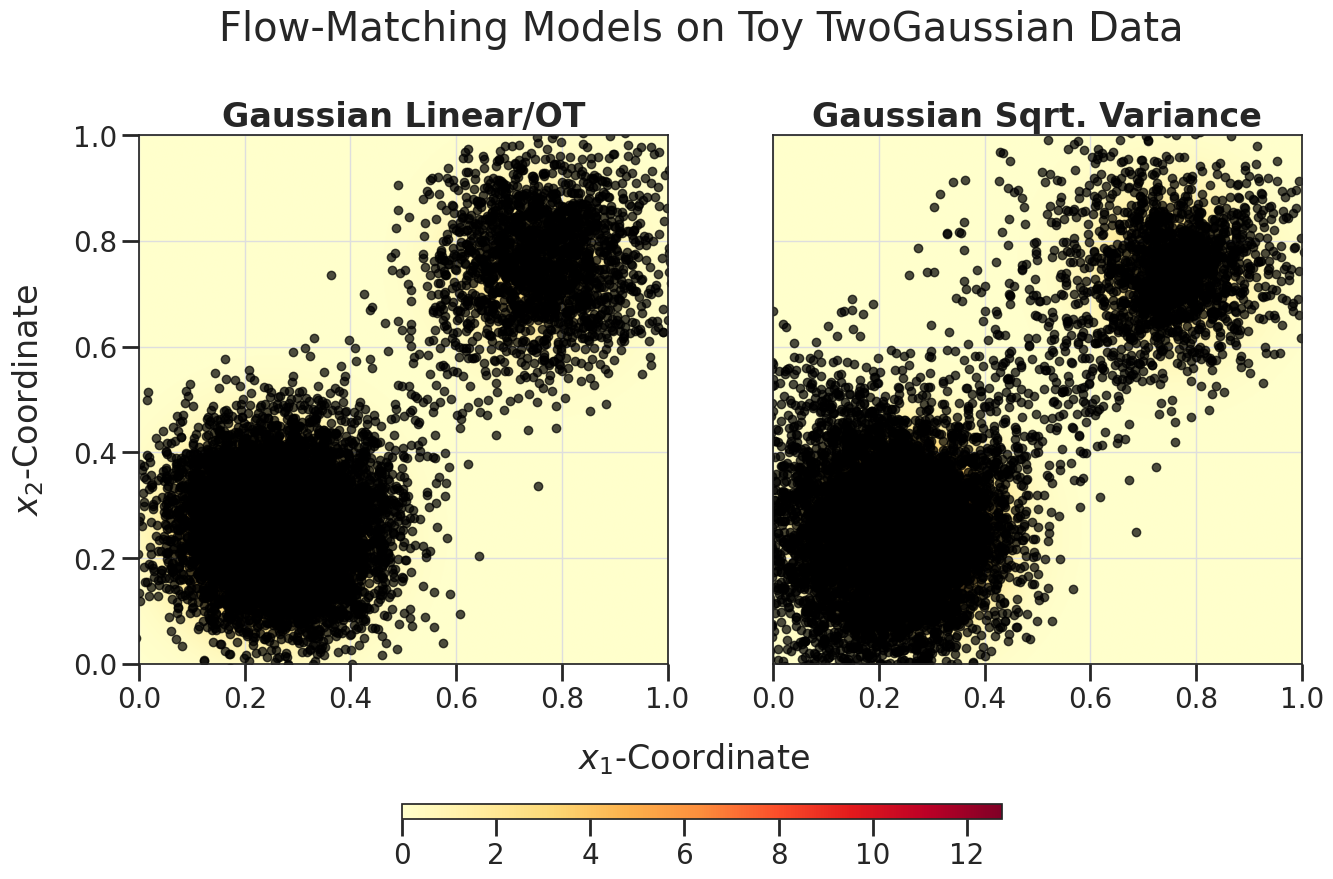

In [14]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)

coordinates = [
    [[x,y] for x in np.linspace(*toy.xlim, 1000)]
    for y in np.linspace(*toy.ylim, 1000)
]
prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

fig = plt.figure(figsize=(15, 15))
gs_plot = fig.add_gridspec(1, 2, bottom=0.1)
gs_cbar = fig.add_gridspec(1, 1, top=0.22, bottom=0.21, left=0.3, right=0.7)

epochs = 3
n_timesteps = 100
embedding_size = 24
hidden_size = 64
for i, (fm_type, make_fun) in enumerate(zip(
    ["gaussot", "gausssqrt"], (
        lambda x_s, h, e, d: make_toy_fm(
            x_s, h, e, schedule=LinearGaussianSchedule, device=d),
        lambda x_s, h, e, d: make_toy_fm(
            x_s, h, e, schedule=SqrtGaussianSchedule, device=d)
    )
)):
    model = make_fun(x_sample_size, hidden_size, embedding_size, DEVICE)
    model.load_state_dict(torch.load(
        MODEL_DIR / f"toy1_{fm_type}_{epochs}_n_epochs.pt",
        map_location=torch.device(DEVICE)
    ))
    with torch.inference_mode():
        model.eval()
        samples = model.sample((10000,))
        samples = samples.detach().cpu().numpy()

    ax = fig.add_subplot(gs_plot[i])
    im = ax.imshow(
        prob, extent=[toy.xlim[0], toy.xlim[1], toy.ylim[0], toy.ylim[1]],
        origin='lower', cmap='YlOrRd'
    )

    ax.scatter(samples[:, 0], samples[:, 1], alpha=0.7, color="black")

    ax.set_xlim(toy.xlim)
    ax.set_ylim(toy.ylim)
    ax.set_aspect("equal")
        
    if i > 0:
        ax.tick_params(left=False, labelleft=False)
        ax.set_ylabel("")
    else:
        ax.set_ylabel("$x_2$-Coordinate", labelpad=20)
    
    if i != 1:
        ax.set_xlabel("")
    else:
        ax.set_xlabel("$x_1$-Coordinate", labelpad=20, x=-0.15)
    
    ax.set_title(FM_NAME_MAP[fm_type], weight="bold")
    
ax_cbar = fig.add_subplot(gs_cbar[0])
fig.colorbar(im, location="bottom", cax=ax_cbar)

fig.suptitle(
    "Flow-Matching Models on Toy TwoGaussian Data", y=0.75)

plt.show()

## 2.2 Chequerboard

In [17]:
# Generate the data
n_data = 10000000
toy = Chequerboard()
train_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)

In [18]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)

epochs = 3
lr = 1e-3

n_timesteps = 100
embedding_size = 24
hidden_size = 64

for fm_type, make_fun in zip(
    ["gaussot", "gausssqrt"], (
        lambda x_s, h, e, d: make_toy_fm(
            x_s, h, e, schedule=LinearGaussianSchedule, device=d),
        lambda x_s, h, e, d: make_toy_fm(
            x_s, h, e, schedule=SqrtGaussianSchedule, device=d)
    )
):
    model = make_fun(x_sample_size, hidden_size, embedding_size, DEVICE)
    n_model_pars = sum(
        p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Number of {fm_type} Parameters: {n_model_pars}.")

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fun = nn.MSELoss()
    model.train()

    total_steps = len(train_loader)*epochs
    progress_bar = tqdm(range(total_steps), desc="Training")
    for epoch in range(epochs):
        for x in train_loader:
            optimizer.zero_grad()

            x = x.to(DEVICE)
            vf_hat, vf = model(x)
            loss = loss_fun(vf_hat, vf)

            loss.backward()
            optimizer.step()

            # Update progress bar
            progress_bar.set_postfix(
                loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
            progress_bar.update()

    torch.save(
        model.state_dict(),
        MODEL_DIR / f"toy2_{fm_type}_{epochs}_n_epochs.pt"
    )

Number of gaussot Parameters: 25702.


Training: 100%|█████████▉| 2999/3000 [01:33<00:00, 42.40it/s, epoch=3/3, loss=⠀      0.4572]

Number of gausssqrt Parameters: 25702.


Training: 100%|██████████| 3000/3000 [01:33<00:00, 32.00it/s, epoch=3/3, loss=⠀      0.4572]


In [19]:
progress_bar.reset()

/home/alzub/tmp/ipykernel_2068479/3079411376.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


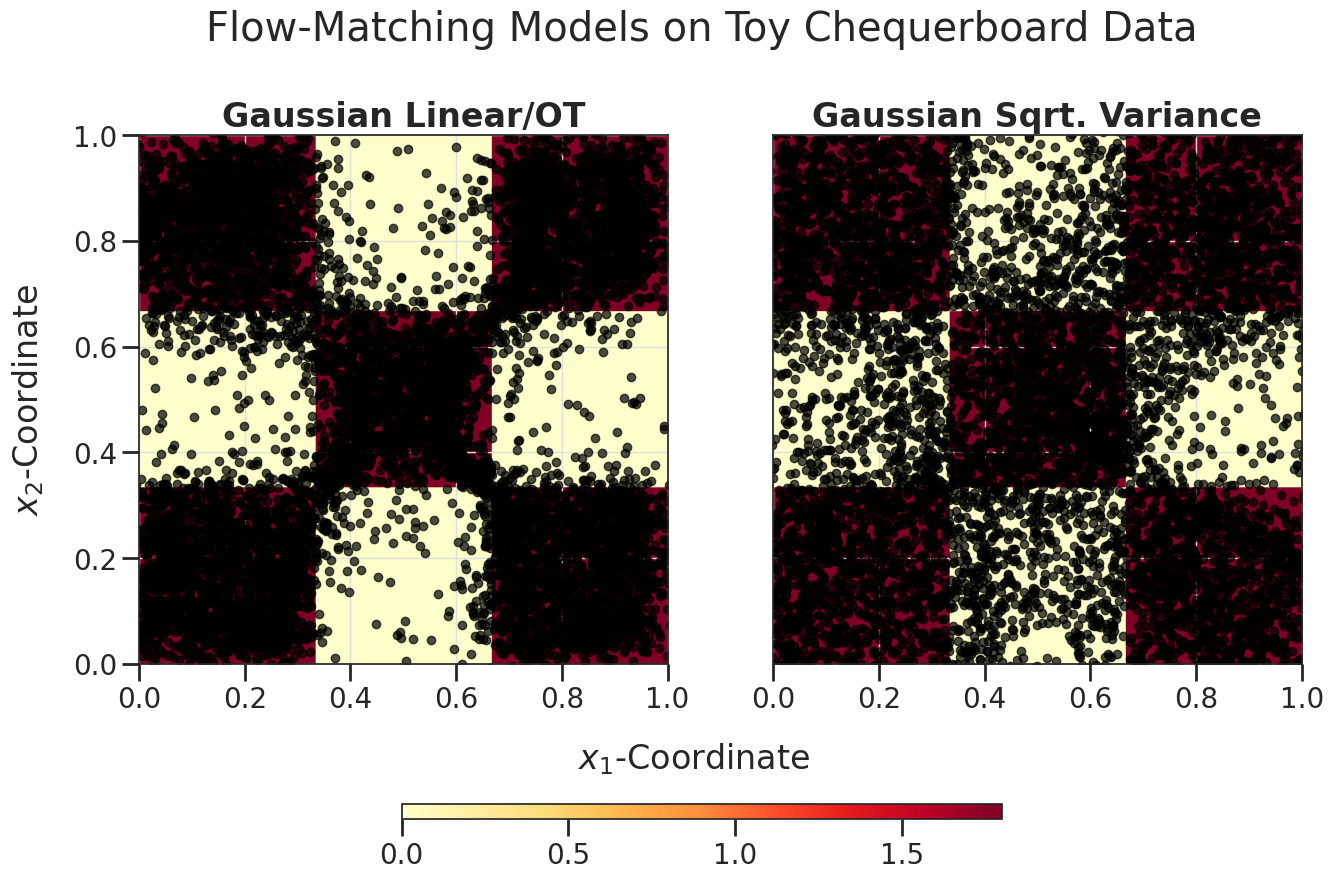

In [ ]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)

coordinates = [
    [[x,y] for x in np.linspace(*toy.xlim, 1000)]
    for y in np.linspace(*toy.ylim, 1000)
]
prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

fig = plt.figure(figsize=(15, 15))
gs_plot = fig.add_gridspec(1, 2, bottom=0.1)
gs_cbar = fig.add_gridspec(1, 1, top=0.22, bottom=0.21, left=0.3, right=0.7)

epochs = 3
n_timesteps = 100
embedding_size = 24
hidden_size = 64
for i, (fm_type, make_fun) in enumerate(zip(
    ["gaussot", "gausssqrt"], (
        lambda x_s, h, e, d: make_toy_fm(
            x_s, h, e, schedule=LinearGaussianSchedule, device=d),
        lambda x_s, h, e, d: make_toy_fm(
            x_s, h, e, schedule=SqrtGaussianSchedule, device=d)
    )
)):
    model = make_fun(x_sample_size, hidden_size, embedding_size, DEVICE)
    model.load_state_dict(torch.load(
        MODEL_DIR / f"toy2_{fm_type}_{epochs}_n_epochs.pt",
        map_location=torch.device(DEVICE)
    ))
    with torch.inference_mode():
        model.eval()
        samples = model.sample((10000,))
        samples = samples.detach().cpu().numpy()

    ax = fig.add_subplot(gs_plot[i])
    im = ax.imshow(
        prob, extent=[toy.xlim[0], toy.xlim[1], toy.ylim[0], toy.ylim[1]],
        origin='lower', cmap='YlOrRd'
    )

    ax.scatter(samples[:, 0], samples[:, 1], alpha=0.7, color="black")

    ax.set_xlim(toy.xlim)
    ax.set_ylim(toy.ylim)
    ax.set_aspect("equal")
        
    if i > 0:
        ax.tick_params(left=False, labelleft=False)
        ax.set_ylabel("")
    else:
        ax.set_ylabel("$x_2$-Coordinate", labelpad=20)
    
    if i != 1:
        ax.set_xlabel("")
    else:
        ax.set_xlabel("$x_1$-Coordinate", labelpad=20, x=-0.15)
    
    ax.set_title(FM_NAME_MAP[fm_type], weight="bold")
    
ax_cbar = fig.add_subplot(gs_cbar[0])
fig.colorbar(im, location="bottom", cax=ax_cbar)

fig.suptitle(
    "Flow-Matching Models on Toy Chequerboard Data", y=0.75)

plt.show()

# 3. Flow-Matching on Easy, Real Data

## 3.1 MNIST

In [ ]:
x_sample = next(iter(mnist_train_loader))[0][:1]
_, n_channels, height, width  = x_sample.size()
epochs = 50

time_embedding_size = 128
class_embedding_size = 128
gamma_hidden = 1024
n_classes = 10
for fm_type in ("gaussot", "gausssqrt"):
    sched = (
        LinearGaussianSchedule
        if fm_type == "gaussot"
        else SqrtGaussianSchedule
    )
    model = make_mnist_fm_model(
        (n_channels, height, width), time_embedding_size, class_embedding_size,
        n_classes=n_classes, schedule=sched, device=DEVICE
    ).to(DEVICE)
    n_model_pars = sum(
        p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Number of {fm_type} Parameters: {n_model_pars}.")

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()

    total_steps = len(mnist_train_loader)*epochs
    progress_bar = tqdm(range(total_steps), desc="Training")
    for epoch in range(epochs):
        for x, y in mnist_train_loader:
            optimizer.zero_grad()

            x, y = x.to(DEVICE), y.to(DEVICE)
            x = dequantize(x)
            vf_hat, vf = model(x, y=y)
            
            loss = loss_fun(vf_hat, vf)

            loss.backward()
            optimizer.step()

            # Update progress bar
            progress_bar.set_postfix(
                loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
            progress_bar.update()

    torch.save(
        model.state_dict(),
        MODEL_DIR
            / f"mnist_{fm_type}_conditional_{epochs}_n_epochs.pt"
    )

Number of gaussot Parameters: 2998691.


Training:   0%|          | 0/2350 [00:27<?, ?it/s, epoch=10/10, loss=⠀      0.2785]


Number of gausssqrt Parameters: 2998691.


Training: 100%|█████████▉| 11749/11750 [12:14<00:00, 18.95it/s, epoch=50/50, loss=⠀      1.2534]

Training: 100%|██████████| 11750/11750 [12:31<00:00, 18.95it/s, epoch=50/50, loss=⠀      1.2534]

In [37]:
progress_bar.reset()

Training:   0%|          | 0/11750 [00:00<?, ?it/s, epoch=50/50, loss=⠀      1.2534]            

In [36]:
x_sample = next(iter(mnist_train_loader))[0][:1]
_, n_channels, height, width  = x_sample.size()
epochs = 50

n_ode_steps = 100
time_embedding_size = 128
class_embedding_size = 128
gamma_hidden = 1024
n_classes = 10
for fm_type in ("gaussot", "gausssqrt"):
    sched = (
        LinearGaussianSchedule
        if fm_type == "gaussot"
        else SqrtGaussianSchedule
    )
    model = make_mnist_fm_model(
        (n_channels, height, width), time_embedding_size, class_embedding_size,
        n_classes=n_classes, schedule=sched, device=DEVICE
    ).to(DEVICE)
    model.load_state_dict(torch.load(
        MODEL_DIR / f"mnist_{fm_type}_conditional_{epochs}_n_epochs.pt",
        map_location=torch.device(DEVICE)
    ))

    # Generate samples
    model.eval()
    with torch.no_grad():
        y = torch.arange(
            10, device=DEVICE, dtype=torch.long).expand((10, 10)).T.flatten()
        samples = (
            model
                .sample((100,), y=y, show_path=False, n_steps=n_ode_steps)
                .detach()
                .cpu()
        )
        samples = samples/2 + 0.5
        save_image(
            samples,
            SAMPLE_DIR / f"mnist_{fm_type}_conditional_{epochs}_n_epochs_{n_ode_steps}_n_steps.png",
            normalize=False, nrow=10
        )

/home/alzub/tmp/ipykernel_2068479/890271631.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


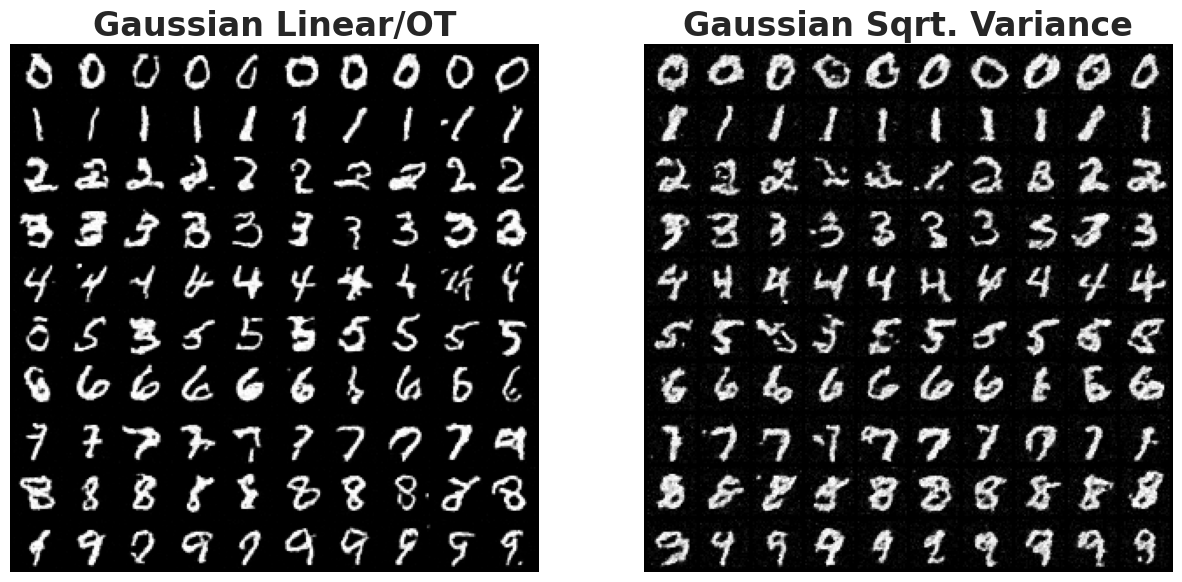

In [41]:
epochs = 50
n_ode_steps = 100

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 10))

for i, fm_type in enumerate(("gaussot", "gausssqrt")):
    img = WImage(
        filename=SAMPLE_DIR
            / f"mnist_{fm_type}_conditional_{epochs}_n_epochs_{n_ode_steps}_n_steps.png"
        )
    ax[i].imshow(img)
    ax[i].set_title(FM_NAME_MAP[fm_type], weight="bold")
    ax[i].axis("off")

plt.show()

# 4. Flow-Matching On Hard, Real Data

## Y. DeFoG Implementation

In [14]:
from torch_geometric.data import InMemoryDataset


class DiscreteGraphBase(nn.Module):
    def __init__(self, dataset: InMemoryDataset, device: str="cpu") -> None:
        super().__init__()
        self.data = dataset
        self.n_graphs = len(dataset)
        self.device = device
        
        self.n_node_states = self.data.x.size(-1)
        self.n_edge_states = self.data.edge_attr.size(-1)
    
    def forward(
        self, return_dist: bool=False
    ) -> Tuple[torch.Tensor|torch.Tensor]|Tuple[td.Distribution, td.Distribution]:
        node_probs = self._make_node_base()
        edge_probs = self._make_edge_base()
        
        if return_dist:
            node_dist = td.Categorical(probs=node_probs)
            edge_dist = td.Categorical(probs=edge_probs)
            return node_dist, edge_dist

        return node_probs, edge_probs
    
    def sample(
        self, node_sample_shape: Tuple[int]=(1,),
        edge_sample_shape: Tuple[int]=(1,), y: torch.Tensor|None=None,
        to_one_hot: bool=True
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        node_dist, edge_dist = self(return_dist=True)
        node_samples = node_dist.sample(node_sample_shape)
        edge_samples = edge_dist.sample(edge_sample_shape)

        if to_one_hot:
            node_samples = F.one_hot(
                node_samples, num_classes=self.n_node_states)
            edge_samples = F.one_hot(
                edge_samples, num_classes=self.n_edge_states)
        
        return node_samples, edge_samples
    
    def _make_node_base(self) -> torch.Tensor:
        raise NotImplementedError
    
    def _make_edge_base(self) -> torch.Tensor:
        raise NotImplementedError

class UniformGraphBase(DiscreteGraphBase):
    def _make_node_base(self) -> torch.Tensor:
        n_states = self.n_node_states
        return torch.tensor(
            [1/n_states]*n_states, dtype=torch.float32, device=self.device)
    
    def _make_edge_base(self) -> torch.Tensor:
        n_states = self.n_edge_states
        return torch.tensor(
            [1/n_states]*n_states, dtype=torch.float32, device=self.device)

class MarginalGraphBase(DiscreteGraphBase):
    def _make_node_base(self):
        tokens = self.data.x.argmax(dim=-1)
        counts = tokens.bincount(minlength=self.n_node_states).float() + 1.0
        return counts / counts.sum()

    def _make_edge_base(self):
        tokens = self.data.edge_attr.argmax(dim=-1)
        counts = tokens.bincount(minlength=self.n_edge_states).float() + 1.0
        return counts / counts.sum()

In [15]:
def extract_triu_node_data(
    edge_index: torch.Tensor, x: torch.Tensor
) -> Tuple[torch.Tensor, torch.Tensor]:
    row, col = edge_index
    upper_mask = row < col
    upper_row, upper_col = row[upper_mask], col[upper_mask]
    x_src, x_dst = x[upper_row], x[upper_col]
    return x_src, x_dst

def extract_triu_edge_data(
    edge_index: torch.Tensor, edge_attr: torch.Tensor) -> torch.Tensor:
    row, col = edge_index
    upper_edge_attr = edge_attr[row < col]
    return upper_edge_attr

def mirror_triu_to_tril_again(
    edge_index: torch.Tensor, edge_attr: torch.Tensor,
    upper_edge_attr: torch.Tensor, n_nodes: int
) -> torch.Tensor:
    edge_attr = edge_attr.clone()

    row, col = edge_index
    upper_mask = row < col
    lower_mask = row > col

    upper_row = row[upper_mask]
    upper_col = col[upper_mask]
    lower_row = row[lower_mask]
    lower_col = col[lower_mask]

    upper_key = upper_row * n_nodes + upper_col
    lower_key = lower_col * n_nodes + lower_row

    order = torch.argsort(upper_key)
    sorted_upper_key = upper_key[order]
    sorted_upper_attr = upper_edge_attr[order]

    lower_pos = torch.searchsorted(sorted_upper_key, lower_key)

    edge_attr[upper_mask] = upper_edge_attr
    edge_attr[lower_mask] = sorted_upper_attr[lower_pos]

    return edge_attr

In [16]:
from torch_geometric.data import Data
from utilities.tensor_utils import broadcast_
from gnn_.utils import get_triu_edge_data, mirror_triu_to_tril


class LinearDiscreteNoiser(nn.Module):
    def __init__(self, base_dist: DiscreteGraphBase) -> None:
        super().__init__()
        self.base = base_dist
    
    def forward(self, batch: Data, t: torch.Tensor) -> Data:
        batch = batch.clone()
        e_idx = batch.edge_index
        row, col = e_idx

        node_attr = batch.x
        t_node = t[batch.batch]

        triu_e_attr = extract_triu_edge_data(e_idx, batch.edge_attr)
        edge_graph = batch.batch[row[row < col]]
        t_edge = t[edge_graph]

        base_node_tokens, base_edge_tokens = self.base.sample(
            node_sample_shape=(t_node.shape[0],),
            edge_sample_shape=(t_edge.shape[0],)
        )
        
        keep_nodes = broadcast_((torch.rand_like(t_node) < t_node), node_attr)
        keep_edges = broadcast_((torch.rand_like(t_edge) < t_edge), triu_e_attr)

        new_node_attr = torch.where(keep_nodes, node_attr, base_node_tokens)
        new_triu_e_attr = torch.where(keep_edges, triu_e_attr, base_edge_tokens)

        batch.x = new_node_attr
        batch.edge_attr = mirror_triu_to_tril_again(
            e_idx, batch.edge_attr, new_triu_e_attr, batch.num_nodes)
        
        return batch

In [ ]:
import torch_geometric.nn as g_nn

from nn_.mlp import MLP
from nn_.embedding import ClassEmbedding, ContinuousSinusoidalPE
from generative.conditioning import FiLMedNetwork, FiLMHybrid


class GNNDenoiser(nn.Module):
    def __init__(
        self, node_feat: int, edge_feat: int, node_hidden: int,
        edge_hidden: int, time_emb_dim: int,
        class_emb_dim: int, n_classes: int, n_layers: int=1,
        updater_layers: int=2, updater_size: int=4,
        message_passing: str="gineconv", act_fun: nn.Module=nn.GELU,
        loader=None
    ) -> None:
        super().__init__()

        self.n_layers = n_layers
    
        self.node_emb = nn.Embedding(node_feat, node_hidden)
        self.edge_emb = nn.Embedding(edge_feat, edge_hidden)

        self.mp_convolutions = nn.ModuleList()
        self.edge_mlps = nn.ModuleList()

        self.node_filmers = nn.ModuleList()
        self.edge_filmers = nn.ModuleList()

        self.node_proj_out = nn.Linear(node_hidden, node_feat)
        self.edge_proj_out = nn.Linear(edge_hidden, edge_feat)

        self.node_norms = nn.ModuleList()
        self.edge_norms = nn.ModuleList()

        for k in range(self.n_layers):
            
            self.mp_convolutions.append(self.conv_create_wrapper(
                message_passing, node_hidden, edge_hidden, updater_size,
                updater_layers, act_fun, loader
            ))
            self.edge_mlps.append(
               MLP(
                    2 * node_hidden + edge_hidden, edge_hidden,
                    [edge_hidden*updater_size]*updater_layers,
                    act_funs=[act_fun]*(updater_layers + 1)
                ) 
            )

            self.node_filmers.append(
                FiLMHybrid(
                    MLP(
                        node_hidden, node_hidden,
                        [node_hidden*updater_size]*updater_layers,
                        act_funs=[act_fun]*(updater_layers + 1)
                    ),
                    ContinuousSinusoidalPE(time_emb_dim),
                    ClassEmbedding(class_emb_dim, n_classes), time_emb_dim,
                    class_emb_dim, node_hidden, act_fun=act_fun
                )
            )
            self.edge_filmers.append(
                FiLMHybrid(
                    MLP(
                        edge_hidden, edge_hidden,
                        [edge_hidden*updater_size]*updater_layers,
                        act_funs=[act_fun]*(updater_layers + 1)
                    ),
                    ContinuousSinusoidalPE(time_emb_dim),
                    ClassEmbedding(class_emb_dim, n_classes), time_emb_dim,
                    class_emb_dim, edge_hidden, act_fun=act_fun
                )
            )

            self.node_norms.append(nn.LayerNorm(node_hidden))
            self.edge_norms.append(nn.LayerNorm(edge_hidden))
    
    def forward(
        self, batch: Data, t: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        e_idx, y = batch.edge_index, batch.y
        row, col = e_idx
        upper_graph = batch.batch[row[row < col]]

        # 1. Embed Tokens to Hidden Representation
        hid_node = self.node_emb(self._as_token_ids(batch.x))
        hid_edge = self.edge_emb(self._as_token_ids(batch.edge_attr))

        # 2. Message-Passing/Updating and Modulation
        for k in range(self.n_layers):
            # 2.1 Nodes
            # 2.1.1 Pass Messages Around
            node_update = self.mp_convolutions[k](
                hid_node, e_idx, edge_attr=hid_edge)
            # 2.1.2 Cast Time and Class to Node Level and Modulate
            t_node, y_node = t[batch.batch], y[batch.batch]
            node_update = self.node_filmers[k](node_update, t_node, y_node)
            # 2.1.3 Residual Connection & Layer Normalization
            hid_node = self.node_norms[k](hid_node + node_update)

            # 2.2 Edges
            # 2.2.1 Extract Upper-Triangular Part
            h_n_src, h_n_tgt = extract_triu_node_data(e_idx, hid_node)
            h_triu_e = extract_triu_edge_data(e_idx, hid_edge)
            # 2.2.2 Update Hidden Edge Features
            triu_e_update = self.edge_mlps[k](torch.cat([
                h_n_src + h_n_tgt, torch.abs(h_n_src - h_n_tgt), h_triu_e
            ], dim=-1))
            # 2.2.3 Cast Time and Class to Edge Level and Modulate
            t_u_e, y_u_e = t[upper_graph], y[upper_graph]
            triu_e_update = self.edge_filmers[k](triu_e_update, t_u_e, y_u_e)
            # 2.2.4 Residual Connection & Layer Normalization
            h_triu_e = self.edge_norms[k](h_triu_e + triu_e_update)
            # 2.2.5 Mirror Final Features Back to "Full Adjacency"
            hid_edge = mirror_triu_to_tril_again(
                e_idx, hid_edge, h_triu_e, batch.num_nodes)
        
        # 3. Project Hidden Embedding To Logits
        node_logits = self.node_proj_out(hid_node)
        edge_logits = self.edge_proj_out(hid_edge)

        return node_logits, edge_logits
    
    def _as_token_ids(self, z: torch.Tensor) -> torch.Tensor:
        if z.dim() == 2:
            z = z.argmax(dim=-1)
        return z.long()
    
    @staticmethod
    def conv_create_wrapper(
        conv_name: str, node_hidden: int, edge_hidden: int, updater_size: int,
        updater_layers: int, act_fun: nn.Module, loader
    ) -> g_nn.MessagePassing:
        if conv_name == "gineconv":
            mp_nn = MLP(
                node_hidden, node_hidden,
                [node_hidden*updater_size]*updater_layers,
                act_funs=[act_fun]*(updater_layers + 1)
            )
            mp_nn.in_channels = node_hidden

            return g_nn.GINEConv(mp_nn, edge_dim=edge_hidden)

        if conv_name == "pna_conv":
            # needs some more tuning and more arguments from __init__
            deg = g_nn.PNAConv.get_degree_histogram(loader)
            return g_nn.PNAConv(
                node_hidden, node_hidden, ["mean", "min", "max", "std"],
                ["identity", "amplification", "attenuation"], deg,
                edge_dim=edge_hidden, act="gelu"
            )

In [18]:
class TinyMLPDenoiser(nn.Module):
    def __init__(
        self,
        num_node_tokens: int,
        num_edge_tokens: int,
        num_classes: int,
        hidden_dim: int = 128,
    ):
        super().__init__()

        self.node_emb = nn.Embedding(num_node_tokens, hidden_dim)
        self.edge_emb = nn.Embedding(num_edge_tokens, hidden_dim)
        self.class_emb = nn.Embedding(num_classes, hidden_dim)

        self.time_mlp = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.node_mlp = nn.Sequential(
            nn.Linear(3 * hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, num_node_tokens),
        )

        self.edge_mlp = nn.Sequential(
            nn.Linear(5 * hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, num_edge_tokens),
        )

    def forward(self, batch, t, y=None):
        if y is None:
            y = batch.y

        x = self._as_token_ids(batch.x)
        edge_attr = self._as_token_ids(batch.edge_attr)
        y = y.long()

        row, col = batch.edge_index

        t_emb_graph = self.time_mlp(t.view(-1, 1))
        y_emb_graph = self.class_emb(y)

        node_graph = batch.batch
        t_node = t_emb_graph[node_graph]
        y_node = y_emb_graph[node_graph]

        x_emb = self.node_emb(x)

        node_input = torch.cat(
            [x_emb, t_node, y_node],
            dim=-1,
        )
        node_logits = self.node_mlp(node_input)

        edge_graph = batch.batch[row]
        t_edge = t_emb_graph[edge_graph]
        y_edge = y_emb_graph[edge_graph]

        edge_emb = self.edge_emb(edge_attr)
        src_emb = x_emb[row]
        dst_emb = x_emb[col]

        edge_input = torch.cat(
            [edge_emb, src_emb, dst_emb, t_edge, y_edge],
            dim=-1,
        )
        edge_logits = self.edge_mlp(edge_input)

        return node_logits, edge_logits
    
    def _as_token_ids(self, z):
        if z.dim() == 2:
            if z.size(-1) == 1:
                z = z.squeeze(-1)
            else:
                z = z.argmax(dim=-1)

        return z.long()

In [19]:
from torch_geometric.data import Batch


def make_initial_sampling_batch(
    batch_size,
    max_n_atoms,
    class_labels,
    base_dist,
    device=None,
):
    data_list = []

    row, col = torch.triu_indices(
        max_n_atoms, max_n_atoms, offset=1, device=device)
    triu_edge_index = torch.stack([row, col], dim=0)
    num_edges = triu_edge_index.size(1)
    edge_index = torch.cat([triu_edge_index, triu_edge_index.flip(0)], dim=1)

    for i in range(batch_size):
        x, upper_edge_attr = base_dist.sample(
            node_sample_shape=(max_n_atoms,), edge_sample_shape=(num_edges,))
        
        edge_attr = torch.cat([upper_edge_attr, upper_edge_attr], dim=0)

        data = Data(
            x=x,
            edge_index=edge_index.clone(),
            edge_attr=edge_attr,
            y=class_labels[i].view(1),
            num_nodes=max_n_atoms,
        )

        data_list.append(data)

    return Batch.from_data_list(data_list)

In [20]:
class LinearDiscreteRateMatrix(nn.Module):
    EPS: float=1e-8
    def __init__(
        self, base_dist: nn.Module, n_node_types: int, n_edge_types: int
    ) -> None:
        super().__init__()
        self.base = base_dist
        self.n_node_types = n_node_types
        self.n_edge_types = n_edge_types
    
    def forward(
        self, current_batch: Data,
        graph_final_token_pred: Tuple[torch.Tensor, torch.Tensor],
        t: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        # 0. Define Helper Variables
        batch = current_batch.clone()
        e_idx = batch.edge_index
        row, col = e_idx
        upper_graph = batch.batch[row[row < col]]

        node_current_tokens, edge_current_tokens = batch.x, batch.edge_attr
        node_final_tokens, edge_final_tokens = graph_final_token_pred

        # 1. Broadcast Time and Extract Upper-Triangular Edge Data
        t_node = t[batch.batch][:, None]
        triu_e_current = extract_triu_edge_data(
            e_idx, edge_current_tokens)
        triu_e_final = extract_triu_edge_data(
            e_idx, edge_final_tokens)
        t_edge = t[upper_graph][:, None]

        # 2.
        d_pt_n, d_pt_e = self.prob_path_rate(
            node_final_tokens, triu_e_final)
        d_pt_n_at_current = d_pt_n.gather(
            -1, node_current_tokens.argmax(dim=-1)[:, None])
        d_pt_e_at_current = d_pt_e.gather(
            -1, triu_e_current.argmax(dim=-1)[:, None])

        # 3.
        pt_n, pt_e = self.prob_path_mass(
            node_final_tokens, triu_e_final, t_node, t_edge)
        n_pos_token_prob = pt_n.count_nonzero(dim=-1)[:, None]
        e_pos_token_prob = pt_e.count_nonzero(dim=-1)[:, None]
        pt_n_at_current = pt_n.gather(
            -1, node_current_tokens.argmax(dim=-1)[:, None])
        pt_e_at_current = pt_e.gather(
            -1, triu_e_current.argmax(dim=-1)[:, None])

        # 4. Calculate KFE-Based Transitional Rates
        rate_mat_nodes = (
            F.relu(d_pt_n - d_pt_n_at_current)
                / (n_pos_token_prob * pt_n_at_current).clamp_min(self.EPS)
        )
        triu_r_e = (
            F.relu(d_pt_e - d_pt_e_at_current)
                / (e_pos_token_prob * pt_e_at_current).clamp_min(self.EPS)
        )

        rate_mat_edges = mirror_triu_to_tril_again(
            e_idx, edge_current_tokens.float(), triu_r_e, batch.num_nodes)
        return rate_mat_nodes, rate_mat_edges

    def prob_path_mass(
        self, n_hat_final: torch.Tensor, e_hat_final: torch.Tensor,
        t_node: torch.Tensor, t_edge: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        n_init, e_init = self.base(return_dist=False)

        pt_n = (
            t_node*F.one_hot(n_hat_final, num_classes=self.n_node_types)
                + (1 - t_node)*n_init.unsqueeze(0)
        )
        pt_e = (
            t_edge*F.one_hot(e_hat_final, num_classes=self.n_edge_types)
                + (1 - t_edge)*e_init.unsqueeze(0)
        )

        return pt_n, pt_e
    
    def prob_path_rate(
        self, n_hat_final: torch.Tensor, e_hat_final: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        n_init, e_init = self.base(return_dist=False)

        d_pt_n = (
            F.one_hot(n_hat_final, num_classes=self.n_node_types)
                - n_init.unsqueeze(0)
        )
        d_pt_e = (
            F.one_hot(e_hat_final, num_classes=self.n_edge_types)
                - e_init.unsqueeze(0)
        )

        return d_pt_n, d_pt_e

In [21]:
from typing import List
from data_proc.mol_preproc import clean_up_graph, mol_from_graph


def batch_to_mols(
    batch: Data, atom_vocab: List[str],
    bond_type_vocab: List[Chem.rdchem.BondType], max_n_atoms: int
) -> List:
    indv_graphs = []
    edge_graph = batch.batch[batch.edge_index[0]]
    for graph_idx in range(batch.num_graphs):
        node_mask = batch.batch == graph_idx
        edge_mask = edge_graph == graph_idx

        x = batch.x[node_mask]
        edge_index = batch.edge_index[:, edge_mask]
        edge_attr = batch.edge_attr[edge_mask]

        g = Data(
            x=x, edge_index=edge_index - edge_index.min(),
            edge_attr=edge_attr, y=batch.y[graph_idx]
        )
        indv_graphs.append(g)
    
    indv_mols = []
    for g in indv_graphs:
        g_clean = clean_up_graph(g, max_n_atoms)
        mol = mol_from_graph(g_clean, atom_vocab, bond_type_vocab)
        indv_mols.append(mol)
    
    return indv_mols

In [ ]:
def euler_rate_to_prob(
    current_tokens: torch.Tensor, rates: torch.Tensor, h: float, eps: float=1e-8
) -> torch.Tensor:
    if current_tokens.dim() == 2:
        current_tokens = current_tokens.argmax(dim=-1)

    step_probs = h * rates
    offdiag_mass = step_probs.sum(dim=-1, keepdim=True)
    stay_prob = (1.0 - offdiag_mass).clamp_min(0.0)
    step_probs = step_probs.scatter(
        dim=-1, index=current_tokens[:, None], src=stay_prob)
    
    step_probs = step_probs.clamp_min(eps)
    step_probs = step_probs / step_probs.sum(dim=-1, keepdim=True)

    return step_probs

In [379]:
class CTMCSampler(nn.Module):
    EPS: float=1e-8
    def __init__(
        self, base_dist: nn.Module, rate_matrix : nn.Module,
        node_classes: int, edge_classes: int, max_nodes: int,
        update_method: str="euler", device: str="cpu",
        bond_types: List["str"]=["single", "double", "triple", "no_bond"]
    ) -> None:
        super().__init__()
        self.base = base_dist
        self.rate_matrix = rate_matrix

        self.nc_nodes, self.nc_edges = node_classes, edge_classes
        self.max_n_nodes = max_nodes

        if update_method == "euler":
            self.update_step = lambda d, b, t, h, u, **kwargs: self.euler_step(
                d, b, t, h, u, self.nc_nodes, self.nc_edges, **kwargs)
        
        self.device = device

        self.bond_types = bond_types
    
    @torch.inference_mode
    def forward(
        self, denoiser: nn.Module,
        sample_shape: Tuple[int]=(1,), n_steps: int=100,
        y: torch.Tensor|None=None, show_path: bool=False,
        t_eval: Tuple[int|float, int|float]=(0., 1.), **kwargs
    ) -> Data|List[Data]:
        batch = self.initial_samples(
            self.base, sample_shape[0], self.max_n_nodes, y=y,
            device=self.device
        )
        if show_path:
            path_samples = [batch]
        
        t0, t_end = t_eval
        t = torch.full((batch.num_graphs,), t0, device=self.device)
        h = torch.full(
            (batch.num_graphs,), (t_end - t0) / n_steps, device=self.device)
        for k in range(n_steps):
            batch, t = self.update_step(
                denoiser, batch, t, h, self.compute_step_probs, **kwargs)
            if show_path:
                path_samples.append(batch)
        
        if show_path:
            return path_samples
        
        return batch

    def compute_step_probs(
        self, denoiser: nn.Module, batch: Data, t: torch.Tensor,
        h: torch.Tensor, bond_order_bias: Tuple[float, float, float]|None=None,
        exit_cap: float|None=None
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        batch = batch.clone()
        e_idx, n_nodes = batch.edge_index, batch.num_nodes
        row, col = e_idx
        upper_graph = batch.batch[row[row < col]]
        h_node, h_edge = h[batch.batch][:, None], h[upper_graph][:, None]

        node_logits, edge_logits = denoiser(batch, t)
        if bond_order_bias:
            dbl_b, tpl_b, ne_b = bond_order_bias
            edge_logits[:, self.bond_types.index("double")] += dbl_b
            edge_logits[:, self.bond_types.index("triple")] += tpl_b
            edge_logits[:, self.bond_types.index("no_bond")] += ne_b
        triu_e_logits = extract_triu_edge_data(e_idx, edge_logits)
        node_final, triu_e_final = self.hard_endpoint_sampling(
            node_logits, triu_e_logits)
        edge_final = mirror_triu_to_tril_again(
            e_idx, edge_logits.argmax(dim=1), triu_e_final, n_nodes)
        
        node_rate, edge_rate = self.rate_matrix(
            batch, (node_final, edge_final), t)
        
        step_prob_node = h_node * node_rate
        step_prob_node = self.normalize_step_probs(
            batch.x, step_prob_node, exit_cap=exit_cap)
        triu_e_prob = h_edge * extract_triu_edge_data(e_idx, edge_rate)
        triu_e_token = extract_triu_edge_data(e_idx, batch.edge_attr)
        triu_e_prob = self.normalize_step_probs(
            triu_e_token, triu_e_prob, exit_cap=exit_cap)
        step_prob_edge = mirror_triu_to_tril_again(
            e_idx, edge_logits, triu_e_prob, n_nodes)
        
        return step_prob_node, step_prob_edge
    
    def normalize_step_probs(
        self, token: torch.Tensor, step_probs: torch.Tensor,
        exit_cap: float|None=None
    ) -> torch.Tensor:
        if token.dim() == 2:
            token = token.argmax(dim=-1)

        offdiag_mass = step_probs.sum(dim=-1, keepdim=True)
        if exit_cap:
            scale = torch.clamp(
                exit_cap / offdiag_mass.clamp_min(self.EPS),
                max=1.0,
            )
            step_probs = step_probs * scale
            offdiag_mass = step_probs.sum(dim=-1, keepdim=True)

        stay_prob = (1.0 - offdiag_mass).clamp_min(0.0)
        step_probs = step_probs.scatter(
            dim=-1, index=token[:, None], src=stay_prob)

        step_probs = step_probs.clamp_min(self.EPS)
        step_probs = step_probs / step_probs.sum(dim=-1, keepdim=True)

        return step_probs

    @staticmethod
    def initial_samples(
        base_dist: nn.Module, batch_size: int, max_n_nodes: int,
        y: torch.Tensor|None=None, device: str="cpu"
    ) -> Data:
        data_list = []

        row, col = torch.triu_indices(
            max_n_nodes, max_n_nodes, offset=1, device=device)
        triu_edge_index = torch.stack([row, col], dim=0)
        num_edges = triu_edge_index.size(1)
        edge_index = torch.cat(
            [triu_edge_index, triu_edge_index.flip(0)], dim=1)

        for i in range(batch_size):
            x, upper_edge_attr = base_dist.sample(
                node_sample_shape=(max_n_nodes,), edge_sample_shape=(num_edges,)
            )
            
            edge_attr = torch.cat([upper_edge_attr, upper_edge_attr], dim=0)
            data = Data(
                x=x,
                edge_index=edge_index.clone(),
                edge_attr=edge_attr,
                y=y[i].view(1) if y is not None else None,
                num_nodes=max_n_nodes,
            )

            data_list.append(data)

        return Batch.from_data_list(data_list).to(device)
    
    @staticmethod
    def hard_endpoint_sampling(
        node_logits: torch.Tensor, edge_logits: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        node_final = (
            torch.distributions.Categorical(logits=node_logits).sample())
        edge_final = (
            torch.distributions.Categorical(logits=edge_logits).sample())
        
        return node_final, edge_final

    @staticmethod
    def euler_step(
        denoiser: nn.Module, batch: Data, t: torch.Tensor, h: torch.Tensor,
        fun: Callable, nc_node: int, nc_edge: int, **kwargs
    ) -> Tuple[torch.Tensor|torch.Tensor]:
        batch = batch.clone()
        e_idx, n_nodes = batch.edge_index, batch.num_nodes

        P_X, P_E = fun(denoiser, batch, t, h, **kwargs)
        t = t + h

        triu_P_E = extract_triu_edge_data(e_idx, P_E)
        node_tokens = torch.distributions.Categorical(probs=P_X).sample()
        triu_e_tokens = torch.distributions.Categorical(probs=triu_P_E).sample()
        edge_tokens = mirror_triu_to_tril_again(
            e_idx, P_E.argmax(dim=1), triu_e_tokens, n_nodes)

        batch = batch.clone()
        batch.x = F.one_hot(node_tokens, num_classes=nc_node)
        batch.edge_attr = F.one_hot(edge_tokens, num_classes=nc_edge)

        return batch, t

## 4.1 MUTAG Molecule Data

In [ ]:
base_dist = MarginalGraphBase(proc_dataset, device=DEVICE)
noiser = LinearDiscreteNoiser(base_dist)

n_atom_tokens = 8
n_bond_tokens = 4
node_hidden_size = 48
edge_hidden_size = 48
time_emb_size = 24
class_emb_size = 24
n_classes = 2
n_update = 3
model = GNNDenoiser(
    n_atom_tokens, n_bond_tokens, node_hidden_size, edge_hidden_size,
    time_emb_size, class_emb_size, n_classes, n_update,
    message_passing="pna_conv", loader=data_loader
).to(DEVICE)
lambda_ = 1.5

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
model.train()
epochs = 500

total_steps = len(data_loader)*epochs
progress_bar = tqdm(range(total_steps), desc="Training")
for epoch in range(epochs):
    for batch in data_loader:
        optimizer.zero_grad()

        t = torch.rand(len(batch), device=batch.x.device)
        noisy_batch = noiser(batch, t)

        node_logits, edge_logits = model(noisy_batch, t)

        node_loss = F.cross_entropy(node_logits, batch.x.float())
        edge_weights = torch.tensor([1.0, 0.8, 0.5, 0.8], device=DEVICE)
        triu_e_attr = extract_triu_edge_data(batch.edge_index, batch.edge_attr)
        triu_e_logits = extract_triu_edge_data(batch.edge_index, edge_logits)
        edge_loss = F.cross_entropy(
            triu_e_logits, triu_e_attr.float(), weight=edge_weights)

        loss = node_loss + lambda_ * edge_loss

        loss.backward()
        optimizer.step()

        # Update progress bar
        progress_bar.set_postfix(
            loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
        progress_bar.update()

Training: 100%|██████████| 2000/2000 [03:21<00:00, 13.82it/s, epoch=500/500, loss=⠀      0.7243]

Training: 100%|██████████| 2000/2000 [03:31<00:00, 13.82it/s, epoch=500/500, loss=⠀      0.7243]

In [295]:
progress_bar.reset()

Training:   0%|          | 0/2000 [00:00<?, ?it/s, epoch=500/500, loss=⠀      0.7243]           

In [335]:
node_classes, edge_classes = 8, 4
sampler = CTMCSampler(
    base_dist, model, LinearDiscreteRateMatrix(
        base_dist, node_classes, edge_classes).to(DEVICE), node_classes,
    edge_classes, TU_MUTAG_CONFIG["max_n_atoms"], device=DEVICE
)

with torch.inference_mode():
    sampler.denoiser.eval()
    n_samples = 100
    n_steps = 100
    y = torch.cat((
        torch.ones((n_samples//2,), dtype=torch.long),
        torch.zeros((n_samples//2,), dtype=torch.long),
    ))

    batch = sampler(
        (n_samples,), y=y, n_steps=n_steps, bond_order_bias=(-0.5, -0.1, 0.5),
        exit_cap=0.5
    )

In [336]:
sampled_mols = batch_to_mols(
    batch, TU_MUTAG_CONFIG["node_list"], KEK_EDGE_LIST_RDK,
    TU_MUTAG_CONFIG["max_n_atoms"]
)

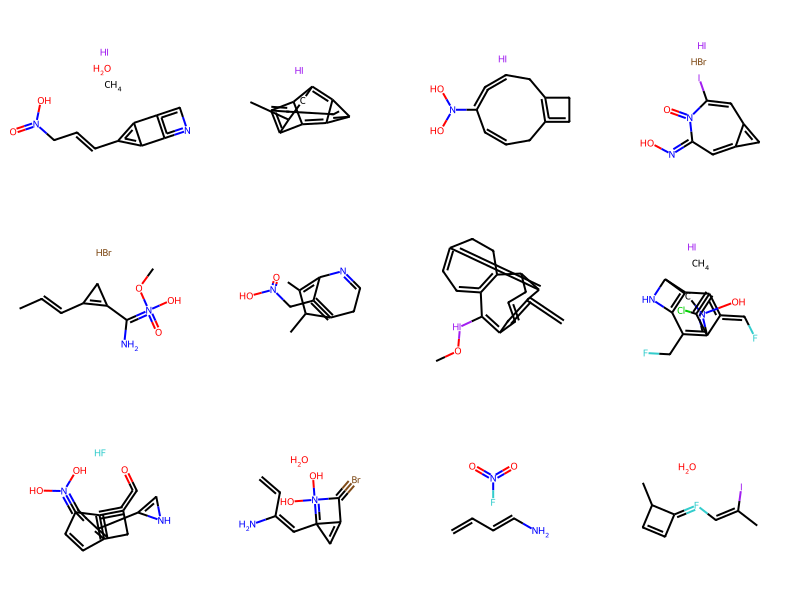

In [337]:
Chem.Draw.MolsToGridImage(
    np.random.choice(sampled_mols, 12, replace=False), molsPerRow=4
)

In [339]:
fully_connected = 0
valid = 0
valid_mols = []
fc_val = 0

for mol in sampled_mols:
    if "." not in Chem.MolToSmiles(mol):
        fully_connected += 1
    try:
        fix_nitro_charges(mol)
        valid += 1
    except:
        pass

    try:
        mol_val = fix_nitro_charges(mol)
        if "." not in Chem.MolToSmiles(mol_val):
            valid_mols.append(mol_val)
            fc_val += 1
    except:
        pass

fc_ratio = fully_connected / n_samples
valid_ratio = valid / n_samples
fc_val_ratio = fc_val / n_samples

print(f"Ratio of fully connected graphs: {fc_ratio*100} %")
print(f"Ratio of chemically valid molecules: {valid_ratio*100} %")
print(f"Ratio of fully connected, valid molecules: {fc_val_ratio*100} % ")

Ratio of fully connected graphs: 32.0 %
Ratio of chemically valid molecules: 30.0 %
Ratio of fully connected, valid molecules: 7.000000000000001 % 


[15:40:56] Explicit valence for atom # 3 C, 5, is greater than permitted
[15:40:56] Explicit valence for atom # 3 C, 5, is greater than permitted
[15:40:56] Explicit valence for atom # 18 C, 5, is greater than permitted
[15:40:56] Explicit valence for atom # 18 C, 5, is greater than permitted
[15:40:56] Explicit valence for atom # 13 C, 5, is greater than permitted
[15:40:56] Explicit valence for atom # 13 C, 5, is greater than permitted
[15:40:56] Explicit valence for atom # 10 C, 5, is greater than permitted
[15:40:56] Explicit valence for atom # 10 C, 5, is greater than permitted
[15:40:56] Explicit valence for atom # 8 C, 5, is greater than permitted
[15:40:56] Explicit valence for atom # 8 C, 5, is greater than permitted
[15:40:56] Explicit valence for atom # 3 C, 5, is greater than permitted
[15:40:56] Explicit valence for atom # 3 C, 5, is greater than permitted
[15:40:56] Explicit valence for atom # 0 N, 5, is greater than permitted
[15:40:56] Explicit valence for atom # 0 N, 5

In [322]:
len(valid_mols)

11

In [378]:
class DeFoG(nn.Module):
    def __init__(
        self, base_dist: nn.Module, noising_process: nn.Module,
          denoiser: nn.Module, sampler: nn.Module, node_tokens: int,
          edge_tokens: int, max_n_nodes: int=35
    ) -> None:
        super().__init__()

        self.base = base_dist
        self.noiser = noising_process
        self.denoiser = denoiser
        self.sampler = sampler
        self.node_tokens = node_tokens
        self.edge_tolens = edge_tokens
        self.max_n_nodes = max_n_nodes
    
    def forward(
        self, batch: Data, edge_loss_weight: float=1.0,
        edge_weights: torch.Tensor=torch.ones(4)
    ) -> torch.Tensor:
        t = torch.rand(len(batch), device=batch.x.device)
        noisy_batch = self.noiser(batch, t)

        node_logits, edge_logits = self.denoiser(noisy_batch, t)

        node_loss = F.cross_entropy(node_logits, batch.x.float())
        edge_weights = edge_weights.to(DEVICE)
        triu_e_attr = extract_triu_edge_data(batch.edge_index, batch.edge_attr)
        triu_e_logits = extract_triu_edge_data(batch.edge_index, edge_logits)
        edge_loss = F.cross_entropy(
            triu_e_logits, triu_e_attr.float(), weight=edge_weights)

        loss = node_loss + edge_loss_weight * edge_loss

        return loss
    
    @torch.inference_mode()
    def sample(
        self, sample_shape=(1,), n_steps: int=100, y: torch.Tensor|None=None,
        show_path: bool=False,
        bond_order_bias: Tuple[float, float, float]=(0., 0., 0.),
        exit_cap: float=0.5
    ) -> torch.Tensor|Tuple[torch.Tensor, torch.Tensor]:
        return self.sampler(
            self.denoiser, sample_shape, y=y, n_steps=n_steps,
            show_path=show_path, bond_order_bias=bond_order_bias,
            exit_cap=exit_cap
        )

In [368]:
base_dist = MarginalGraphBase(proc_dataset, device=DEVICE)
noiser = LinearDiscreteNoiser(base_dist)
n_atom_tokens, n_bond_tokens = 8, 4
node_hidden_siz, edge_hidden_sizee = 48, 48
time_emb_size, class_emb_size = 24, 24
n_classes = 2
n_update = 3
denoiser = GNNDenoiser(
    n_atom_tokens, n_bond_tokens, node_hidden_size, edge_hidden_size,
    time_emb_size, class_emb_size, n_classes, n_update,
    message_passing="pna_conv", loader=data_loader
).to(DEVICE)
sampler = CTMCSampler(
    base_dist, LinearDiscreteRateMatrix(
        base_dist, node_classes, edge_classes).to(DEVICE), n_atom_tokens,
    n_bond_tokens, TU_MUTAG_CONFIG["max_n_atoms"], device=DEVICE
)
model = DeFoG(
    base_dist, noiser, denoiser, sampler, n_atom_tokens, n_bond_tokens,
    TU_MUTAG_CONFIG["max_n_atoms"]
).to(DEVICE)

lambda_ = 1.5
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
model.train()
epochs = 100

total_steps = len(data_loader)*epochs
progress_bar = tqdm(range(total_steps), desc="Training")
for epoch in range(epochs):
    for batch in data_loader:
        optimizer.zero_grad()

        loss = model(
            batch, edge_loss_weight=lambda_,
            edge_weights=torch.tensor([1.0, 0.8, 0.5, 0.8])
        )

        loss.backward()
        optimizer.step()

        # Update progress bar
        progress_bar.set_postfix(
            loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
        progress_bar.update()
    
    torch.save(
        model.state_dict(),
        MODEL_DIR
            / f"mutag_defog_conditional_{epochs}_n_epochs.pt"
    )

Training: 100%|█████████▉| 399/400 [00:34<00:00, 13.94it/s, epoch=100/100, loss=⠀      0.8349]

In [369]:
progress_bar.reset()

Training:   0%|          | 0/400 [00:00<?, ?it/s, epoch=100/100, loss=⠀      0.8349]          

In [380]:
base_dist = MarginalGraphBase(proc_dataset, device=DEVICE)
noiser = LinearDiscreteNoiser(base_dist)
n_atom_tokens, n_bond_tokens = 8, 4
node_hidden_siz, edge_hidden_sizee = 48, 48
time_emb_size, class_emb_size = 24, 24
n_classes = 2
n_update = 3
denoiser = GNNDenoiser(
    n_atom_tokens, n_bond_tokens, node_hidden_size, edge_hidden_size,
    time_emb_size, class_emb_size, n_classes, n_update,
    message_passing="pna_conv", loader=data_loader
).to(DEVICE)
sampler = CTMCSampler(
    base_dist, LinearDiscreteRateMatrix(
        base_dist, node_classes, edge_classes).to(DEVICE), n_atom_tokens,
    n_bond_tokens, TU_MUTAG_CONFIG["max_n_atoms"], device=DEVICE
)
model = DeFoG(
    base_dist, noiser, denoiser, sampler, n_atom_tokens, n_bond_tokens,
    TU_MUTAG_CONFIG["max_n_atoms"]
).to(DEVICE)

model.load_state_dict(torch.load(
    MODEL_DIR / f"mutag_defog_conditional_{epochs}_n_epochs.pt",
    map_location=torch.device(DEVICE)
))

with torch.inference_mode():
    model.eval()
    n_samples = 100
    n_steps = 100
    y = torch.cat((
        torch.ones((n_samples//2,), dtype=torch.long),
        torch.zeros((n_samples//2,), dtype=torch.long),
    ))

    batch = model.sample(
        (n_samples,), y=y, n_steps=n_steps, bond_order_bias=(-0.5, -0.1, 0.5),
        exit_cap=0.5
    )

/home/alzub/tmp/ipykernel_2332362/2073517329.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


In [381]:
sampled_mols = batch_to_mols(
    batch, TU_MUTAG_CONFIG["node_list"], KEK_EDGE_LIST_RDK,
    TU_MUTAG_CONFIG["max_n_atoms"]
)

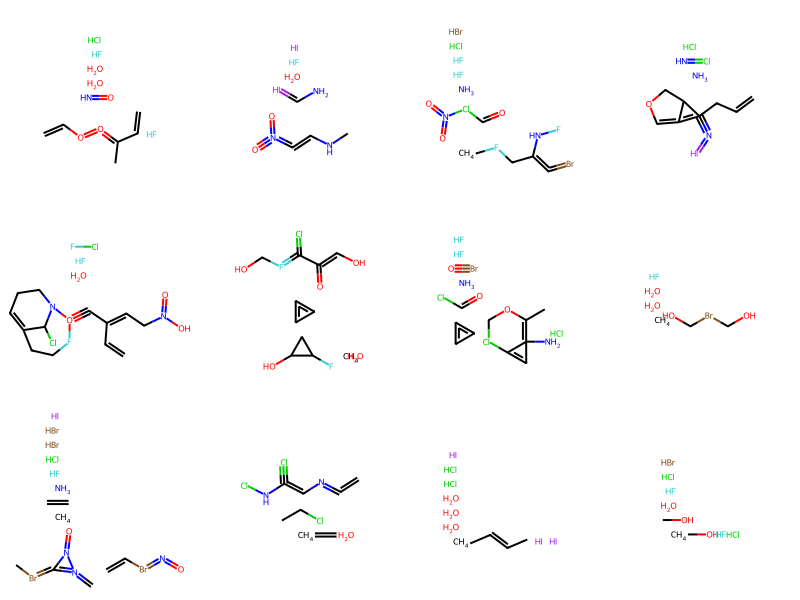

In [383]:
Chem.Draw.MolsToGridImage(
    np.random.choice(sampled_mols, 12, replace=False), molsPerRow=4
)

In [384]:
fully_connected = 0
valid = 0
valid_mols = []
fc_val = 0

for mol in sampled_mols:
    if "." not in Chem.MolToSmiles(mol):
        fully_connected += 1
    try:
        fix_nitro_charges(mol)
        valid += 1
    except:
        pass

    try:
        mol_val = fix_nitro_charges(mol)
        if "." not in Chem.MolToSmiles(mol_val):
            valid_mols.append(mol_val)
            fc_val += 1
    except:
        pass

fc_ratio = fully_connected / n_samples
valid_ratio = valid / n_samples
fc_val_ratio = fc_val / n_samples

print(f"Ratio of fully connected graphs: {fc_ratio*100} %")
print(f"Ratio of chemically valid molecules: {valid_ratio*100} %")
print(f"Ratio of fully connected, valid molecules: {fc_val_ratio*100} % ")

Ratio of fully connected graphs: 1.0 %
Ratio of chemically valid molecules: 23.0 %
Ratio of fully connected, valid molecules: 0.0 % 


[16:58:47] Explicit valence for atom # 2 N, 4, is greater than permitted
[16:58:47] Explicit valence for atom # 2 N, 4, is greater than permitted
[16:58:47] Explicit valence for atom # 1 O, 4, is greater than permitted
[16:58:47] Explicit valence for atom # 1 O, 4, is greater than permitted
[16:58:47] Explicit valence for atom # 9 Cl, 3, is greater than permitted
[16:58:47] Explicit valence for atom # 9 Cl, 3, is greater than permitted
[16:58:47] Explicit valence for atom # 13 C, 5, is greater than permitted
[16:58:47] Explicit valence for atom # 13 C, 5, is greater than permitted
[16:58:47] Explicit valence for atom # 0 N, 5, is greater than permitted
[16:58:47] Explicit valence for atom # 0 N, 5, is greater than permitted
[16:58:47] Explicit valence for atom # 13 Cl, 2, is greater than permitted
[16:58:47] Explicit valence for atom # 13 Cl, 2, is greater than permitted
[16:58:47] Explicit valence for atom # 5 F, 2, is greater than permitted
[16:58:47] Explicit valence for atom # 5 F,

### HPO

In [349]:
from mealpy import Problem, FloatVar, IntegerVar, StringVar, MixedSetVar
from mealpy.utils.space import BaseVar
from typing import Iterable
from numpy import ndarray
from rdkit import rdBase


DEFOG_BOUNDS = [
    MixedSetVar(valid_sets=[32, 48, 64, 96], name="node_hidden"),
    MixedSetVar(valid_sets=[32, 48, 64, 96], name="edge_hidden"),
    MixedSetVar(valid_sets=[32, 48, 64, 96], name="time_emb_size"),
    MixedSetVar(valid_sets=[32, 48, 64, 96], name="class_emb_size"),
    IntegerVar(lb=1, ub=5, name="n_layers"),
    FloatVar(lb=0.5, ub=4.0, name="lambda_eloss"),
    FloatVar(lb=0.3, ub=1.0, name="dbl_weight"),
    FloatVar(lb=0.05, ub=0.5, name="tpl_weight"),
    FloatVar(lb=0.8, ub=2.0, name="ne_weight"),
    FloatVar(lb=-1.5, ub=-0.5, name="dbl_bias"),
    FloatVar(lb=-4.0, ub=-1.0, name="tpl_bias"),
    FloatVar(lb=0.0, ub=1.0, name="ne_bias"),
    FloatVar(lb=0.2, ub=0.8, name="rate_exit_cap"),
]

class DeFoGMolSearchProblem(Problem):
    def __init__(
        self, bounds: Iterable[BaseVar]|None=None, minmax: str="min",
        train_loader=None, test_loader=None, n_epochs: int=100,
        n_solv_steps: int=100, n_samples: int=100, device: str="cpu",
        **kwargs
    ) -> None:
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.n_epochs = n_epochs
        self.n_solv_steps = n_solv_steps
        self.n_samples = n_samples
        self.device = device
        super().__init__(bounds, minmax, **kwargs)
    
    def obj_func(self, x: ndarray) -> float:
        x_decoded = self.decode_solution(x)
        
        #try:
        base_dist = MarginalGraphBase(proc_dataset, device=DEVICE)
        noiser = LinearDiscreteNoiser(base_dist)

        n_atom_tokens = 8
        n_bond_tokens = 4
        node_hidden_size = x_decoded["node_hidden"]
        edge_hidden_size = x_decoded["edge_hidden"]
        time_emb_size = x_decoded["time_emb_size"]
        class_emb_size = x_decoded["class_emb_size"]
        n_classes = 2
        n_update = x_decoded["n_layers"]
        model = GNNDenoiser(
            n_atom_tokens, n_bond_tokens, node_hidden_size, edge_hidden_size,
            time_emb_size, class_emb_size, n_classes, n_update,
            message_passing="pna_conv", loader=data_loader
        ).to(DEVICE)
        lambda_ = x_decoded["lambda_eloss"]

        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        model.train()

        for epoch in range(self.n_epochs):
            for batch in self.train_loader:
                optimizer.zero_grad()

                t = torch.rand(len(batch), device=batch.x.device)
                noisy_batch = noiser(batch, t)

                node_logits, edge_logits = model(noisy_batch, t)

                node_loss = F.cross_entropy(node_logits, batch.x.float())
                edge_weights = torch.tensor(
                    [
                        1.0, x_decoded["dbl_weight"],
                        x_decoded["tpl_weight"], x_decoded["ne_weight"]
                    ],
                    device=DEVICE
                )
                triu_e_attr = extract_triu_edge_data(batch.edge_index, batch.edge_attr)
                triu_e_logits = extract_triu_edge_data(batch.edge_index, edge_logits)
                edge_loss = F.cross_entropy(
                    triu_e_logits, triu_e_attr.float(), weight=edge_weights)

                loss = node_loss + lambda_ * edge_loss

                loss.backward()
                optimizer.step()
        
        node_classes, edge_classes = 8, 4
        sampler = CTMCSampler(
            base_dist, model, LinearDiscreteRateMatrix(
                base_dist, node_classes, edge_classes).to(DEVICE), node_classes,
            edge_classes, TU_MUTAG_CONFIG["max_n_atoms"], device=DEVICE
        )

        fc_val_ratio = 0
        for i in range(10):
            with torch.inference_mode():
                sampler.denoiser.eval()
                n_samples = self.n_samples
                n_steps = self.n_solv_steps
                y = torch.ones((n_samples,), dtype=torch.long)

                batch = sampler(
                    (n_samples,), y=y, n_steps=n_steps,
                    bond_order_bias=(
                        x_decoded["dbl_bias"], x_decoded["dbl_bias"],
                        x_decoded["dbl_bias"]
                    ), exit_cap=x_decoded["rate_exit_cap"]
                )
            
            sampled_mols = batch_to_mols(
                batch, TU_MUTAG_CONFIG["node_list"], KEK_EDGE_LIST_RDK,
                TU_MUTAG_CONFIG["max_n_atoms"]
            )

            fully_connected = 0
            valid = 0
            valid_mols = []
            fc_val = 0

            with rdBase.BlockLogs():
                for mol in sampled_mols:
                    if "." not in Chem.MolToSmiles(mol):
                        fully_connected += 1
                    try:
                        fix_nitro_charges(mol)
                        valid += 1
                    except:
                        pass

                    try:
                        mol_val = fix_nitro_charges(mol)
                        if "." not in Chem.MolToSmiles(mol_val):
                            valid_mols.append(mol_val)
                            fc_val += 1
                    except:
                        pass

            fc_val_ratio += fc_val / n_samples
        
        fc_val_ratio /= 10

        del model
        import gc
        gc.collect()
        torch.cuda.empty_cache() 

        return 1. - fc_val_ratio
        #except:
        #    return 1.

In [354]:
from mealpy.evolutionary_based.SHADE import L_SHADE

problem = DeFoGMolSearchProblem(
    DEFOG_BOUNDS, train_loader=data_loader, test_loader=data_loader,
    n_epochs=300, n_solv_steps=100, n_samples=100, device=DEVICE
)

optimizer_hpo = L_SHADE(epoch=10, pop_size=5)
optimizer_hpo.solve(problem, seed=42)

2026/04/27 04:08:02 PM, INFO, mealpy.evolutionary_based.SHADE.L_SHADE: Solving single objective optimization problem.
2026/04/27 04:19:04 PM, INFO, mealpy.evolutionary_based.SHADE.L_SHADE: >>>Problem: P, Epoch: 1, Current best: 0.964, Global best: 0.964, Runtime: 359.98026 seconds
2026/04/27 04:24:35 PM, INFO, mealpy.evolutionary_based.SHADE.L_SHADE: >>>Problem: P, Epoch: 2, Current best: 0.964, Global best: 0.964, Runtime: 330.53609 seconds
2026/04/27 04:30:54 PM, INFO, mealpy.evolutionary_based.SHADE.L_SHADE: >>>Problem: P, Epoch: 3, Current best: 0.964, Global best: 0.964, Runtime: 378.95767 seconds
2026/04/27 04:36:41 PM, INFO, mealpy.evolutionary_based.SHADE.L_SHADE: >>>Problem: P, Epoch: 4, Current best: 0.9339999999999999, Global best: 0.9339999999999999, Runtime: 347.17773 seconds
2026/04/27 04:43:23 PM, INFO, mealpy.evolutionary_based.SHADE.L_SHADE: >>>Problem: P, Epoch: 5, Current best: 0.9339999999999999, Global best: 0.9339999999999999, Runtime: 401.64773 seconds


KeyboardInterrupt: 